In [131]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Parametrii Digital Twin

In [132]:
GRID_SIZE = 150
D_O2 = 0.1 # coeficient de difuzie scalat pentru grid
LAMBDA_O2 = 0.044
O2_BOUNDARY = 220.0
O2_HYPOXIA = 10.0
O2_NECROSIS = 1.0
PROB_DIV_BASE = 0.04
DIFUSION_STEP = 1000


# Initialization Lattice

In [133]:
# Initialization Lattice
grid_celule = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
grid_oxigen = np.full((GRID_SIZE, GRID_SIZE), O2_BOUNDARY, dtype=float)

mid = GRID_SIZE // 2

# Setăm raza inițială a agregatului celular (în număr de "pixeli/celule")
raza_initiala = 7

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        # Dacă distanța de la centru până la punctul (i,j) este mai mică decât raza, pune o celulă vie
        if (i - mid)**2 + (j - mid)**2 <= raza_initiala**2:
            grid_celule[i, j] = 1

NUMAR_INITIAL_CELULE = np.sum(grid_celule > 0)
FACTOR_IESIRE_LATENTA = 2.345 # iesire din latenta la aprox 2.35 generatii de celule
PRAG_ADAPTIV_CELULE = NUMAR_INITIAL_CELULE * FACTOR_IESIRE_LATENTA

# O2_DEF

In [134]:
def difuzie_oxigen(oxigen_vechi, celule):
    oxigen_nou = np.copy(oxigen_vechi)
    
    # Decupam matricea pentru a obtine vecinii tuturor celulelor SIMULTAN
    O_sus    = oxigen_vechi[:-2, 1:-1]
    O_jos    = oxigen_vechi[2:,  1:-1]
    O_stanga = oxigen_vechi[1:-1, :-2]
    O_dreapta= oxigen_vechi[1:-1, 2:]
    O_centru = oxigen_vechi[1:-1, 1:-1]
    
    # Laplacian discret calculat pentru toata grila in milisecunde
    laplacian = O_sus + O_jos + O_stanga + O_dreapta - 4 * O_centru
    
    # Consumul aplicat doar unde celulele au valoarea 1
    consum = np.where(celule[1:-1, 1:-1] == 1, LAMBDA_O2, 0.0)
    
    # Actualizam partea interioara a grilei dintr-un foc
    oxigen_nou[1:-1, 1:-1] = O_centru + (D_O2 * laplacian) - consum
    
    return np.clip(oxigen_nou, 0.0, O2_BOUNDARY)

# Biology Update

In [ ]:

def update_biologie(celule, oxigen):
    celule_noi = np.copy(celule)
    numar_celule = np.sum(celule > 0)

    # simulare efect lag
    if numar_celule < PRAG_ADAPTIV_CELULE:
        PROB_DIV_BASE = 0.011
    else :
        PROB_DIV_BASE = 0.044

    for i in range(1, GRID_SIZE - 1):
        for j in range(1, GRID_SIZE - 1):
            if celule[i, j] == 1: # Celulă vie
                nivel_O2 = oxigen[i, j]
                
                # Regula 1: Necroza
                if nivel_O2 <= O2_NECROSIS:
                    celule_noi[i, j] = 2 
                    continue
                
                # Regula 2: Hipoxia
                if nivel_O2 <= O2_HYPOXIA:
                    continue 
                
                if np.random.rand() < PROB_DIV_BASE:
                    vecini_liberi = []
                    # Căutăm spațiu
                    if celule[i+1, j] == 0: vecini_liberi.append((i+1, j))
                    if celule[i-1, j] == 0: vecini_liberi.append((i-1, j))
                    if celule[i, j+1] == 0: vecini_liberi.append((i, j+1))
                    if celule[i, j-1] == 0: vecini_liberi.append((i, j-1))
                    
                    if vecini_liberi:
                        nou_i, nou_j = vecini_liberi[np.random.randint(len(vecini_liberi))]
                        celule_noi[nou_i, nou_j] = 1
                        
    return celule_noi

# Main Loop

In [ ]:
zile_de_simulat = 35
ore_totale = zile_de_simulat * 24

istoric_volum = []
axa_timp = []

print("Simularea a inceput. Calculez...")
for ora in range(ore_totale):
    
    # Difuzia
    for _ in range(DIFUSION_STEP):
        grid_oxigen = difuzie_oxigen(grid_oxigen, grid_celule)
        
    grid_celule = update_biologie(grid_celule, grid_oxigen)
    
    # Salvăm datele o dată la 24 de ore
    if ora % 24 == 0:
        ziua_curenta = ora // 24
        volum_curent = np.sum(grid_celule > 0) # Celule Vii + Necrotice
        
        istoric_volum.append(volum_curent)
        axa_timp.append(ziua_curenta)
        print(f"Ziua {ziua_curenta} finalizata | Volum: {volum_curent} celule")

# Salvăm ultima valoare
istoric_volum.append(np.sum(grid_celule > 0))
axa_timp.append(zile_de_simulat)

Simularea a inceput. Calculez...
Ziua 0 finalizata | Volum: 149 celule
Ziua 1 finalizata | Volum: 157 celule
Ziua 2 finalizata | Volum: 177 celule
Ziua 3 finalizata | Volum: 184 celule
Ziua 4 finalizata | Volum: 201 celule
Ziua 5 finalizata | Volum: 214 celule
Ziua 6 finalizata | Volum: 228 celule
Ziua 7 finalizata | Volum: 240 celule
Ziua 8 finalizata | Volum: 260 celule
Ziua 9 finalizata | Volum: 275 celule
Ziua 10 finalizata | Volum: 294 celule
Ziua 11 finalizata | Volum: 310 celule
Ziua 12 finalizata | Volum: 332 celule
Ziua 13 finalizata | Volum: 391 celule
Ziua 14 finalizata | Volum: 479 celule
Ziua 15 finalizata | Volum: 589 celule
Ziua 16 finalizata | Volum: 709 celule
Ziua 17 finalizata | Volum: 837 celule
Ziua 18 finalizata | Volum: 947 celule
Ziua 19 finalizata | Volum: 1080 celule
Ziua 20 finalizata | Volum: 1229 celule
Ziua 21 finalizata | Volum: 1376 celule
Ziua 22 finalizata | Volum: 1538 celule
Ziua 23 finalizata | Volum: 1714 celule
Ziua 24 finalizata | Volum: 1897 cel

# Plotting

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\david\AppData\Local\Temp\ipykernel_10488\2035262318.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax[1].set_title("Harta Oxigenului ($\mu$M)")


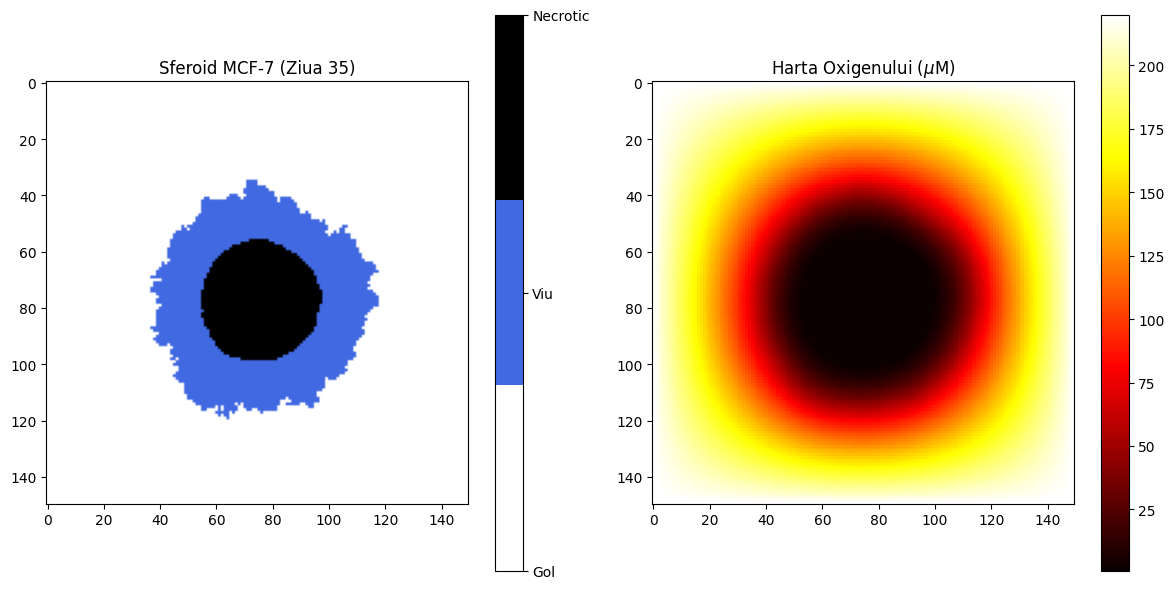

In [137]:
cmap_celule = mcolors.ListedColormap(['white', 'royalblue', 'black'])
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im1 = ax[0].imshow(grid_celule, cmap=cmap_celule, vmin=0, vmax=2)
ax[0].set_title(f"Sferoid MCF-7 (Ziua {zile_de_simulat})")
fig.colorbar(im1, ax=ax[0], ticks=[0, 1, 2], format=plt.FuncFormatter(lambda val, loc: ['Gol', 'Viu', 'Necrotic'][val]))

im2 = ax[1].imshow(grid_oxigen, cmap='hot', interpolation='nearest')
ax[1].set_title("Harta Oxigenului ($\mu$M)")
fig.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()

# Conversie la volum

In [138]:
import numpy as np

DIAMETRU_CELULA_UM = 20.0 # micrometri
RAZA_CELULA_UM = DIAMETRU_CELULA_UM / 2.0

aria_celula_um2 = np.pi * (RAZA_CELULA_UM ** 2)

def conversie_2D_in_Volum_3D(numar_celule):

    aria_totala_um2 = numar_celule * aria_celula_um2
    raza_sferoid_um = np.sqrt(aria_totala_um2 / np.pi)
    volum_um3 = (4/3) * np.pi * (raza_sferoid_um ** 3)
    
    # Conversie din micrometri cubi în milimetri cubi (1 mm³ = 10^9 µm³)
    volum_mm3 = volum_um3 / 1e9
    
    return volum_mm3

istoric_volum_mm3 = [conversie_2D_in_Volum_3D(n) for n in istoric_volum]

# Date reale

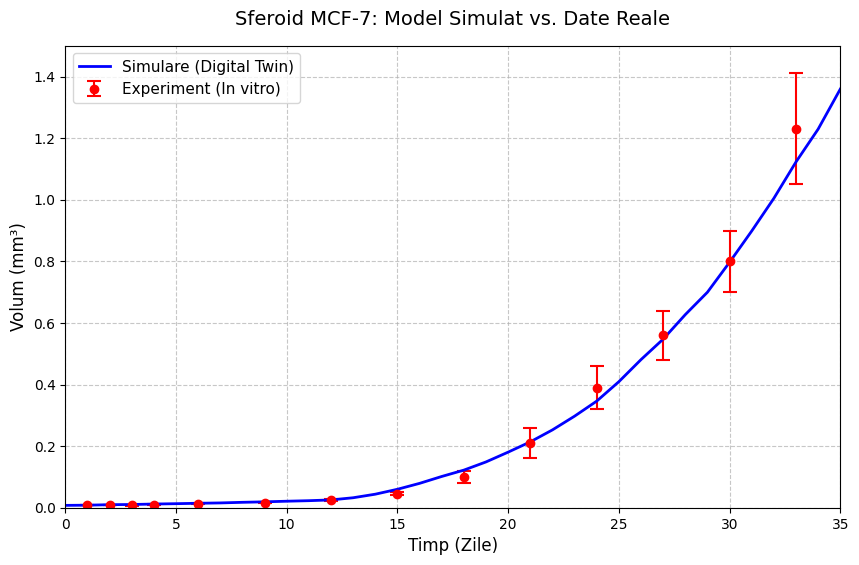

In [139]:
import numpy as np
import matplotlib.pyplot as plt

# Datele tale
zile_articol = np.array([1, 2, 3, 4, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33])
volum_articol_mm3 = np.array([0.009, 0.0085, 0.008, 0.0095, 0.013, 0.016, 0.024, 0.045, 0.10, 0.21, 0.39, 0.56, 0.80, 1.23])
erori_volum = np.array([0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.003, 0.005, 0.02, 0.05, 0.07, 0.08, 0.10, 0.18])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=zile_articol, 
    y=volum_articol_mm3, 
    yerr=erori_volum, 
    fmt='ro',             
    capsize=5,            
    capthick=1.5,         
    label='Experiment (In vitro)'
)

plt.plot(
    axa_timp, 
    istoric_volum_mm3, 
    'b-',                 
    linewidth=2,
    label='Simulare (Digital Twin)'
)

plt.title('Sferoid MCF-7: Model Simulat vs. Date Reale', fontsize=14, pad=15)
plt.xlabel('Timp (Zile)', fontsize=12)
plt.ylabel('Volum (mm³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)

plt.xlim(0, 35) 
plt.ylim(0, 1.5) 

plt.show()